## 베이직반 통계 1차시 복습퀴즈 

### Baseline (주어진 코드)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [3]:
folder_path = r"C:\python_course\통계학\1,2회차 복습 퀴즈/" #########--------------------- 자기 경로로 수정하기!
article_df = pd.read_csv(folder_path+"articles_hm.csv")
customer_df = pd.read_csv(folder_path+"customer_hm.csv")
transaction_df = pd.read_csv(folder_path+"transactions_hm.csv")

In [4]:
whole_df = pd.merge(
    pd.merge(
        transaction_df,
        customer_df,
        on = 'customer_id'
    ),
    article_df,
    on ='article_id'
)
df = whole_df[['t_dat','customer_id','Active','age','section_no','section_name','index_group_no','index_group_name','product_type_no','product_type_name','price']].copy()
df['price'] = df['price']*1000

### 3. price를 히스토그램으로 그렸을 때 그래프는 어느쪽으로 솟아있나요?  
### 4. price의 히스토그램을 해석한 결과로 틀린 것은? 

<Axes: >

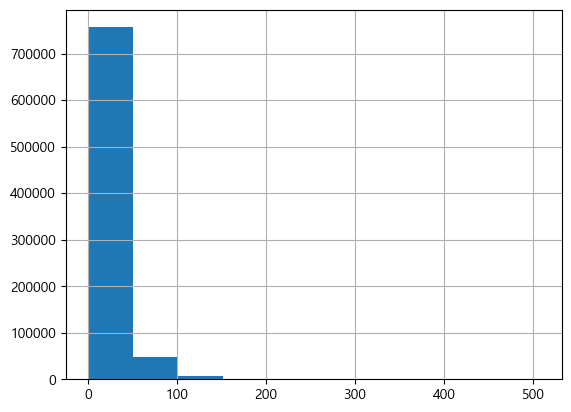

In [5]:
df['price'].hist()
# 왼쪽으로 치우쳐 솟아있다.

### 5. age의 표준편차를 입력해주세요(소수점 둘째자리까지) 
### 6. price의 제3사분위수(75%)를 입력해주세요 (소수점 둘째자리까지) 

In [10]:
age_df = df['age']

print(age_df.describe())
# 5. std는 표준편차란 뜻. 고로 13.01

df['price'].describe()
# 6. 33.88

count   812931.00
mean        36.36
std         13.01
min         16.00
25%         26.00
50%         32.00
75%         48.00
max         99.00
Name: age, dtype: float64


count   812931.00
mean        27.77
std         19.32
min          0.24
25%         15.24
50%         25.41
75%         33.88
max        506.78
Name: price, dtype: float64

### 7. price를 iqr 방식으로 처리했을 때, 이상치로 분류되는 데이터의 행 개수는 몇 개인가요?

In [12]:
q_1 = np.percentile(df['price'], q=25)
q_3 = np.percentile(df['price'], q=75)
iqr = q_3 - q_1

lower_whisker = q_1 - 1.5 * iqr
upper_whisker = q_3 + 1.5 * iqr

In [15]:
df.loc[(df['price'] < lower_whisker) | (df['price'] > upper_whisker)]

outliar = df.loc[(df['price'] < lower_whisker) | (df['price'] > upper_whisker)]
# 38557개
outliar

,t_dat,customer_id,Active,age,section_no,section_name,index_group_no,index_group_name,product_type_no,product_type_name,price
13,2019-12-16,60ddf2a3025c0d258e6e36a49ef4552dc1387ef9101ef0...,0,27,15,Womens Everyday Collection,1,Ladieswear,265,Dress,152.53
36,2019-11-05,af009bb3c25a04b40141dccee0dbddae745f8605f2e560...,1,27,57,Ladies Denim,2,Divided,272,Trousers,84.73
81,2019-09-12,bb662fafda64d7623825257ef73b8f726b93d48948fd63...,0,34,8,Mama,1,Ladieswear,272,Trousers,67.78
87,2019-11-13,a6ccf7f0366a494bab9b92063066a060d6dbb20fd29d35...,1,29,64,Womens Shoes,1,Ladieswear,90,Pumps,101.68
151,2019-09-25,111a15bce93afd74f15e28b58b3c353cb6df2bf3f9d773...,1,67,57,Ladies Denim,2,Divided,272,Trousers,84.73
...,...,...,...,...,...,...,...,...,...,...,...
812865,2019-12-06,8ad59d85354cbb6be1dd27fb6ea399674002e7fd7f1bdd...,1,52,23,Men Suits & Tailoring,3,Menswear,264,Blazer,101.68
812869,2019-04-22,607bde8769e0d7ea2c19e025db2eecfdc68620312c73c2...,0,25,57,Ladies Denim,2,Divided,262,Jacket,67.78
812895,2019-03-28,5b712ec2c675ca9c4a2949795aed3c0ff5a35c845c9b22...,1,27,57,Ladies Denim,2,Divided,272,Trousers,67.78
812903,2019-03-04,025c705b7d9f959782e5b4e62ddfde1950335aec4e7f65...,1,23,19,Womens Jackets,1,Ladieswear,262,Jacket,101.68


In [18]:
df_cleaned = df.loc[(df['price'] >= lower_whisker) & (df['price'] <= upper_whisker)]
df_cleaned

,t_dat,customer_id,Active,age,section_no,section_name,index_group_no,index_group_name,product_type_no,product_type_name,price
0,2019-11-05,3e2b60b679e62fb49516105b975560082922011dd752ec...,1,51,53,Divided Collection,2,Divided,252,Sweater,16.93
1,2019-05-22,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,0,28,6,Womens Casual,1,Ladieswear,254,Top,33.88
2,2019-05-10,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,1,37,21,Contemporary Casual,3,Menswear,274,Shorts,16.93
3,2019-08-26,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,0,19,65,Womens Big accessories,1,Ladieswear,66,Bag,33.88
4,2019-08-10,3b77905de8b32045f08cedb79200cdfa477e9562429a39...,0,35,26,Men Underwear,3,Menswear,302,Socks,3.22
...,...,...,...,...,...,...,...,...,...,...,...
812926,2019-03-25,8e900818a1da0e73300a012794615993fbefb43f851430...,0,21,15,Womens Everyday Collection,1,Ladieswear,273,Leggings/Tights,25.41
812927,2019-10-18,13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...,1,39,15,Womens Everyday Collection,1,Ladieswear,265,Dress,16.93
812928,2019-04-06,5f51e21397c1248aafdf9712435bd4be063eb093f56229...,1,44,56,Denim Men,3,Menswear,272,Trousers,21.73
812929,2019-03-20,3421bd479ee13287a65660cf816b01d0d803d1d6d0fe73...,0,51,16,Womens Everyday Basics,1,Ladieswear,272,Trousers,16.93


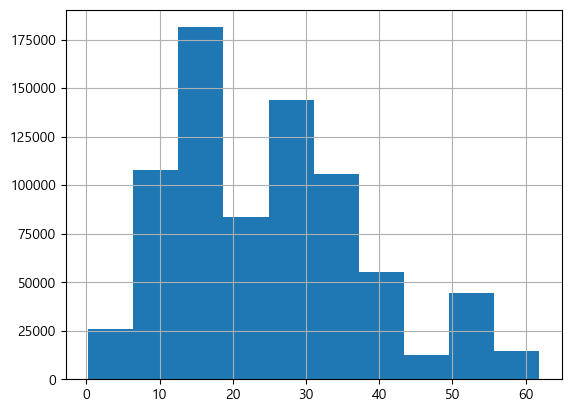

In [29]:
df_cleaned['price'].hist(bins = 10)